# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

* Write your notebook objective here, for example, "Fetch data from Kaggle and save as raw data", or "engineer features for modelling"

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/mohammedluqmanriaz/Desktop/Code Instatute/capstone_try_two/2025_capstone_project/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/mohammedluqmanriaz/Desktop/Code Instatute/capstone_try_two/2025_capstone_project'

# Section 1

Section 1 content

Import the data that is going to be cleaned 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('jupyter_notebooks/Data_set/transactions.csv')  # Make sure this path is correct


In [5]:
# Updated function to create a data dictionary
def create_data_dictionary(df):
    descriptions = {
        'transaction_id': 'Unique identifier for each transaction',
        'customer_id': 'Unique identifier assigned to each customer (e.g., CUSTXXXXX)',
        'transaction_date': 'Date and time when the transaction occurred',
        'transaction_type': 'Type of transaction (e.g., UPI, Debit Card, Bill Payment)',
        'transaction_amount': 'Amount involved in the transaction'
    }

    dictionary_data = []
    for column in df.columns:
        sample_values = df[column].dropna().head(3).tolist()
        sample_str = ', '.join([str(x) for x in sample_values])
        
        dictionary_data.append({
            'Column': column,
            'Data Type': str(df[column].dtype),
            'Missing Values': df[column].isnull().sum(),
            'Missing %': round((df[column].isnull().sum() / len(df)) * 100, 2),
            'Unique Values': df[column].nunique(),
            'Sample Values': sample_str,
            'Description': descriptions.get(column, 'Custom/Engineered column - description needed')
        })
        
    return pd.DataFrame(dictionary_data)

# Generate and display the data dictionary
raw_data_dictionary = create_data_dictionary(df)
print(raw_data_dictionary)

# Optional: Save to file
# raw_data_dictionary.to_csv('data_dictionary.csv', index=False)

                               Column Data Type  Missing Values  Missing %  \
0                      transaction_id    object               0        0.0   
1                         customer_id    object               0        0.0   
2                    transaction_date    object               0        0.0   
3                    transaction_type    object               0        0.0   
4                  transaction_amount   float64               0        0.0   
5                   merchant_category    object               0        0.0   
6                       merchant_name    object               0        0.0   
7                transaction_location    object               0        0.0   
8   account_balance_after_transaction   float64               0        0.0   
9        is_international_transaction     int64               0        0.0   
10                        device_used    object               0        0.0   
11                         ip_address    object               0 

Create a dictionary for the data set

In [6]:
# Check for duplicate customer IDs
duplicate_customer_ids = df[df.duplicated(subset='customer_id', keep=False)]
duplicate_customer_count = duplicate_customer_ids['customer_id'].nunique()
print(f"\nNumber of duplicate customer IDs: {duplicate_customer_count}")
print("Duplicate customer ID records:")
print(duplicate_customer_ids.sort_values(by='customer_id').head(10))  # Display first 10 for brevity

# Check for duplicate transaction IDs
duplicate_transaction_ids = df[df.duplicated(subset='transaction_id', keep=False)]
duplicate_transaction_count = duplicate_transaction_ids['transaction_id'].nunique()
print(f"\nNumber of duplicate transaction IDs: {duplicate_transaction_count}")
if duplicate_transaction_count > 0:
    print("Duplicate transaction ID records:")
    print(duplicate_transaction_ids.sort_values(by='transaction_id'))
else:
    print("No duplicate transaction IDs found.")


Number of duplicate customer IDs: 14256
Duplicate customer ID records:
                             transaction_id customer_id     transaction_date  \
40586  832f55da-cf8c-4631-9056-d93e9c3b69df  CUST100000  2022-01-15 19:37:00   
8200   ee57f580-a235-48b8-a562-bdfc09061af4  CUST100000  2022-01-20 15:33:00   
32002  eacc300c-a6f4-4c24-9e33-734618fbc363  CUST100001  2022-01-20 19:20:00   
40783  dcefbaad-116c-446b-9a53-2fefa2c93ab3  CUST100001  2022-01-04 18:10:00   
27843  ec304a78-a139-4b56-a6f3-a56a6f9a965c  CUST100001  2022-01-25 17:19:00   
37407  6c3aa45b-6723-4317-9b1b-fb1e7884a2d3  CUST100003  2022-01-04 17:27:00   
26373  0392509a-fcc9-4d11-9130-784af62f3b2b  CUST100003  2022-01-25 09:15:00   
31660  e67bc3a2-f581-4741-be79-233b4c1c2691  CUST100003  2022-01-01 05:18:00   
32667  03a54f00-fa13-41a5-ad5e-f4974aa606ba  CUST100005  2022-01-18 11:15:00   
7140   db28cc87-b314-41b0-8e2c-d113ebb365ad  CUST100005  2022-01-21 03:28:00   

        transaction_type  transaction_amount   

---

Show all duplicates within Transactions COL and Customer ID Col

In [7]:
df.isnull().sum()

transaction_id                       0
customer_id                          0
transaction_date                     0
transaction_type                     0
transaction_amount                   0
merchant_category                    0
merchant_name                        0
transaction_location                 0
account_balance_after_transaction    0
is_international_transaction         0
device_used                          0
ip_address                           0
transaction_status                   0
transaction_source_destination       0
transaction_notes                    0
fraud_flag                           0
dtype: int64

Decide:

Drop rows/columns

Fill with mean/median/mode/forward-fill (for time series)

Impute or flag as unknown


Check for Duplicates
You've already done this, but to summarize:

Check for duplicate rows entirely:

python

Edit
df.duplicated().sum()
Remove them if necessary:

python

df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

Validate Data Types

In [9]:
df.dtypes

transaction_id                        object
customer_id                           object
transaction_date                      object
transaction_type                      object
transaction_amount                   float64
merchant_category                     object
merchant_name                         object
transaction_location                  object
account_balance_after_transaction    float64
is_international_transaction           int64
device_used                           object
ip_address                            object
transaction_status                    object
transaction_source_destination        object
transaction_notes                     object
fraud_flag                             int64
dtype: object

Convert date strings to datetime


In [10]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

Check for Outliers in Numeric Columns
within the transaction amount

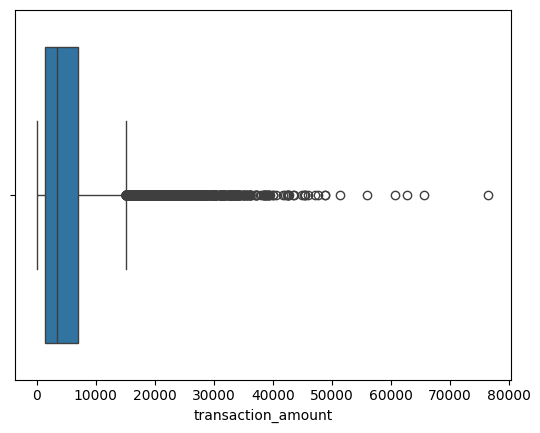

In [11]:
sns.boxplot(x=df['transaction_amount'])
plt.show()

Check for Invalid or Inconsistent Entries
Negative amounts? (e.g., refunds or errors)

Unrecognized transaction types?

In [12]:
df['transaction_type'].value_counts()
df[~df['customer_id'].str.startswith('CUST')]

,transaction_id,customer_id,transaction_date,transaction_type,transaction_amount,merchant_category,merchant_name,transaction_location,account_balance_after_transaction,is_international_transaction,device_used,ip_address,transaction_status,transaction_source_destination,transaction_notes,fraud_flag


Standardize Categorical Values
Make sure categories are consistent:

In [13]:
df['transaction_type'] = df['transaction_type'].str.strip().str.title()

Check Date Ranges
Ensure transaction_date is within expected limits (e.g., not in the future):

In [14]:
df[df['transaction_date'] > pd.Timestamp.today()]

,transaction_id,customer_id,transaction_date,transaction_type,transaction_amount,merchant_category,merchant_name,transaction_location,account_balance_after_transaction,is_international_transaction,device_used,ip_address,transaction_status,transaction_source_destination,transaction_notes,fraud_flag


Remove Unnecessary Columns
If there are columns that:

Contain only one value

Are irrelevant to your analysis

You can remove them:

In [15]:
#df = df.drop(columns=['column_name'])

Handle Zero or Near-Zero Variance Columns
Columns with almost no variance may not be useful:

In [16]:
df.nunique()

transaction_id                       50000
customer_id                          18318
transaction_date                     30012
transaction_type                        10
transaction_amount                     639
merchant_category                       12
merchant_name                        35312
transaction_location                  8823
account_balance_after_transaction    30267
is_international_transaction             2
device_used                              4
ip_address                           50000
transaction_status                       2
transaction_source_destination       39993
transaction_notes                       12
fraud_flag                               2
dtype: int64

Save as a new file

In [17]:
df.to_csv('jupyter_notebooks/Data_set/transactions_clean.csv', index=False)

# Section 2

Section 2 content

Adding Matplotlip graphs to the cleansed data in order to show:

📉 Transaction counts by type

📦 Transaction amount spread per type

📈 Daily transaction volume trend

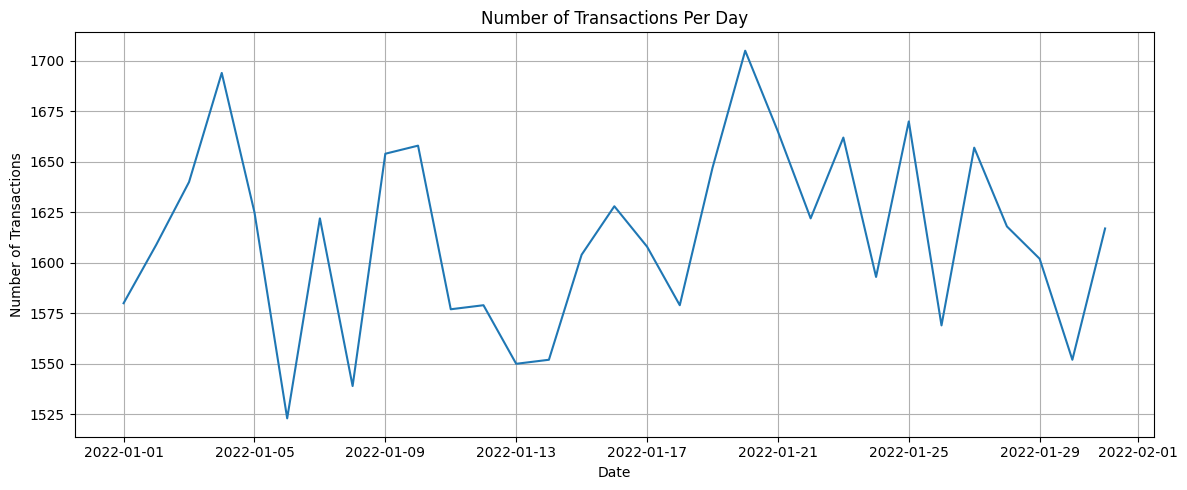

In [18]:
df_daily = df.groupby(df['transaction_date'].dt.date).size()
plt.figure(figsize=(12, 5))
df_daily.plot()
plt.title('Number of Transactions Per Day')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.tight_layout()
plt.show()

📊 Transaction amount distribution

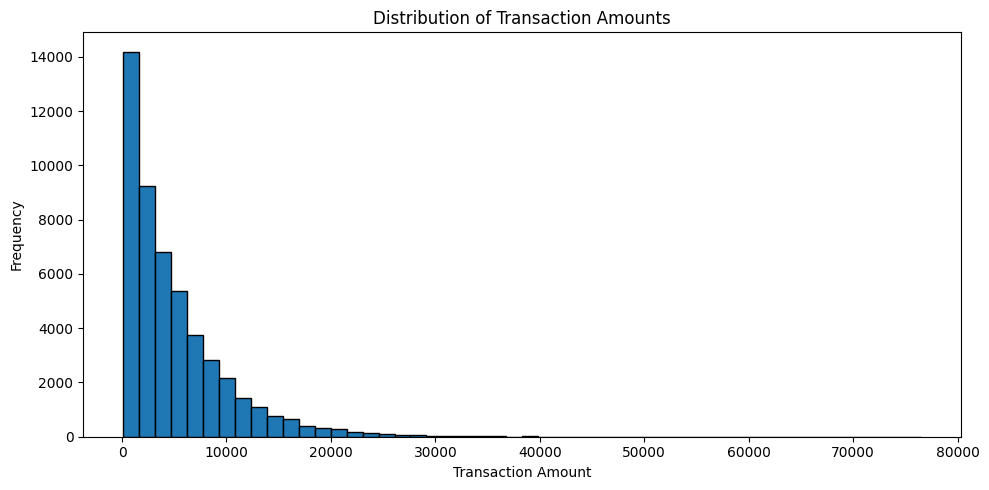

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(df['transaction_amount'], bins=50, edgecolor='black')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

📉 Transaction counts by type

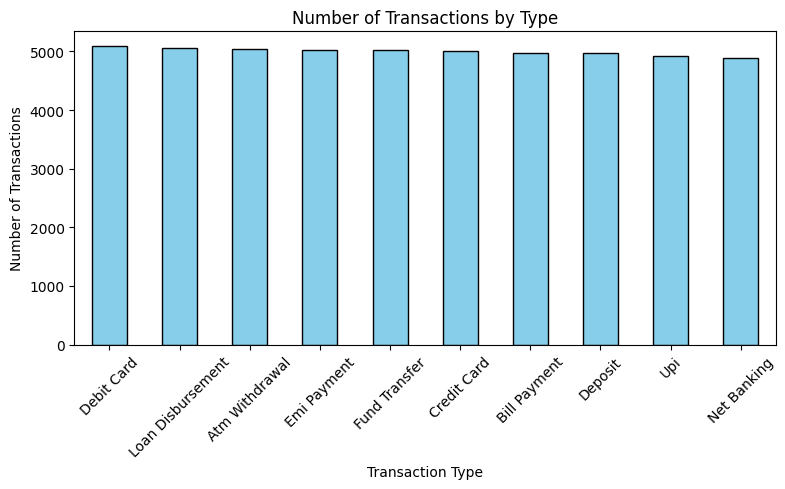

In [20]:
df_type_counts = df['transaction_type'].value_counts()
plt.figure(figsize=(8, 5))
df_type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

📦 Transaction amount spread per type

<Figure size 1000x600 with 0 Axes>

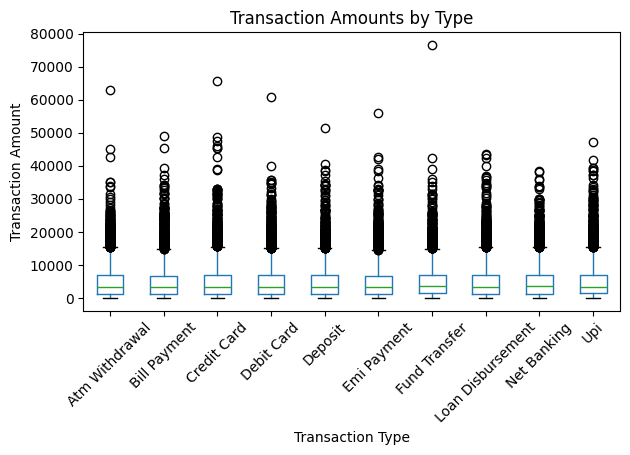

In [21]:
plt.figure(figsize=(10, 6))
df.boxplot(column='transaction_amount', by='transaction_type', grid=False)
plt.title('Transaction Amounts by Type')
plt.suptitle('')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Machine Learning:

Machine Learning Plan

- Goal for Classification: Predict transaction_type based on transaction_amount, customer_id, and transaction_date.

- Goal for Regression: Predict transaction_amount from other features.

Model Types:

- DecisionTreeClassifier & DecisionTreeRegressor

- RandomForestClassifier & RandomForestRegressor

- Graphs to Generate:

- Feature Importance Plot

- Decision Tree Visualization

- Predicted vs. Actual Scatter Plot (Regression)

- Confusion Matrix (Classification)


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score
#import seaborn as sns

# Convert dates

In [23]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['hour'] = df['transaction_date'].dt.hour

Encode categorical variables

In [24]:
le_type = LabelEncoder()
df['transaction_type_encoded'] = le_type.fit_transform(df['transaction_type'])

# ---------------- CLASSIFICATION MODEL ----------------

In [25]:
X_class = df[['transaction_amount', 'day_of_week', 'hour']]
y_class = df['transaction_type_encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=5, random_state=42)

# Confusion Matrix

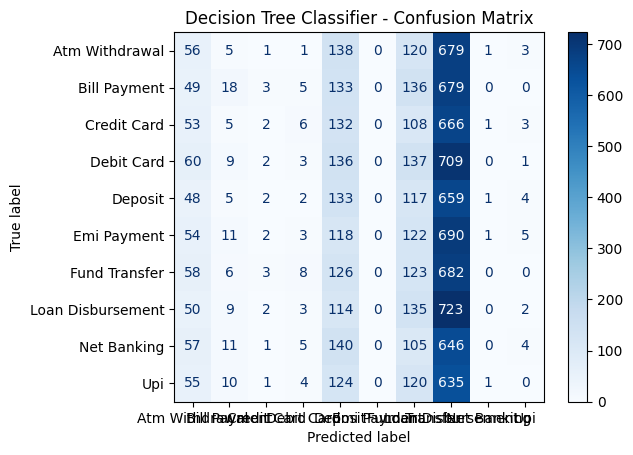

In [26]:
y_pred_c = clf.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_c)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_type.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Decision Tree Classifier - Confusion Matrix")
plt.show()


# Feature Importance (Classification)

In [27]:
X_reg = df[['day_of_week', 'hour', 'transaction_type_encoded']]
y_reg = df['transaction_amount']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = DecisionTreeRegressor(max_depth=5, random_state=42)
reg.fit(X_train_r, y_train_r)

DecisionTreeRegressor(max_depth=5, random_state=42)

# Predictions

In [28]:
y_pred_r = reg.predict(X_test_r)

# Scatter Plot: Actual vs Predicted

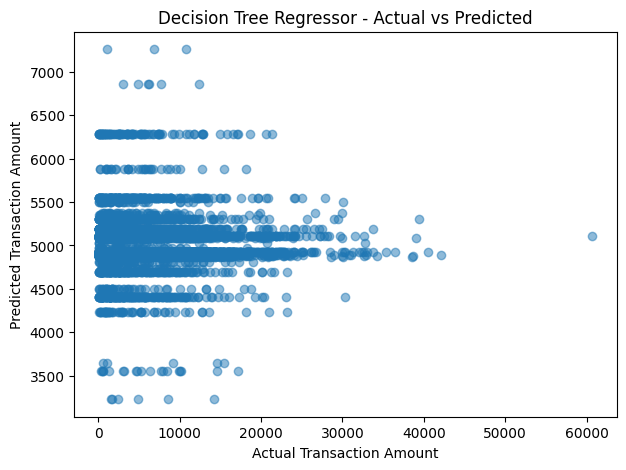

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_r, y_pred_r, alpha=0.5)
plt.xlabel("Actual Transaction Amount")
plt.ylabel("Predicted Transaction Amount")
plt.title("Decision Tree Regressor - Actual vs Predicted")
plt.show()

# Feature Importance (Regression)

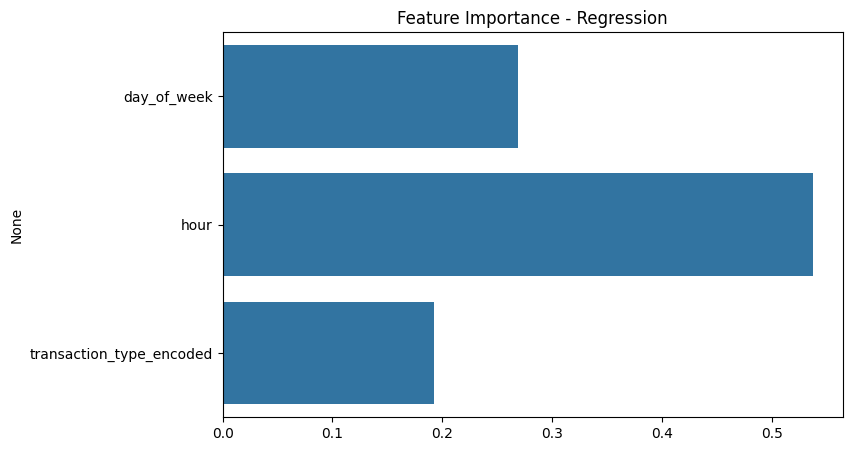

In [30]:
plt.figure(figsize=(8, 5))
sns.barplot(x=reg.feature_importances_, y=X_reg.columns)
plt.title("Feature Importance - Regression")
plt.show()

# Metrics

In [31]:
print(f"Regression RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")
print(f"Regression R²: {r2_score(y_test_r, y_pred_r):.2f}")

Regression RMSE: 5005.01
Regression R²: -0.00


# ---------------- TREE VISUALIZATION ----------------

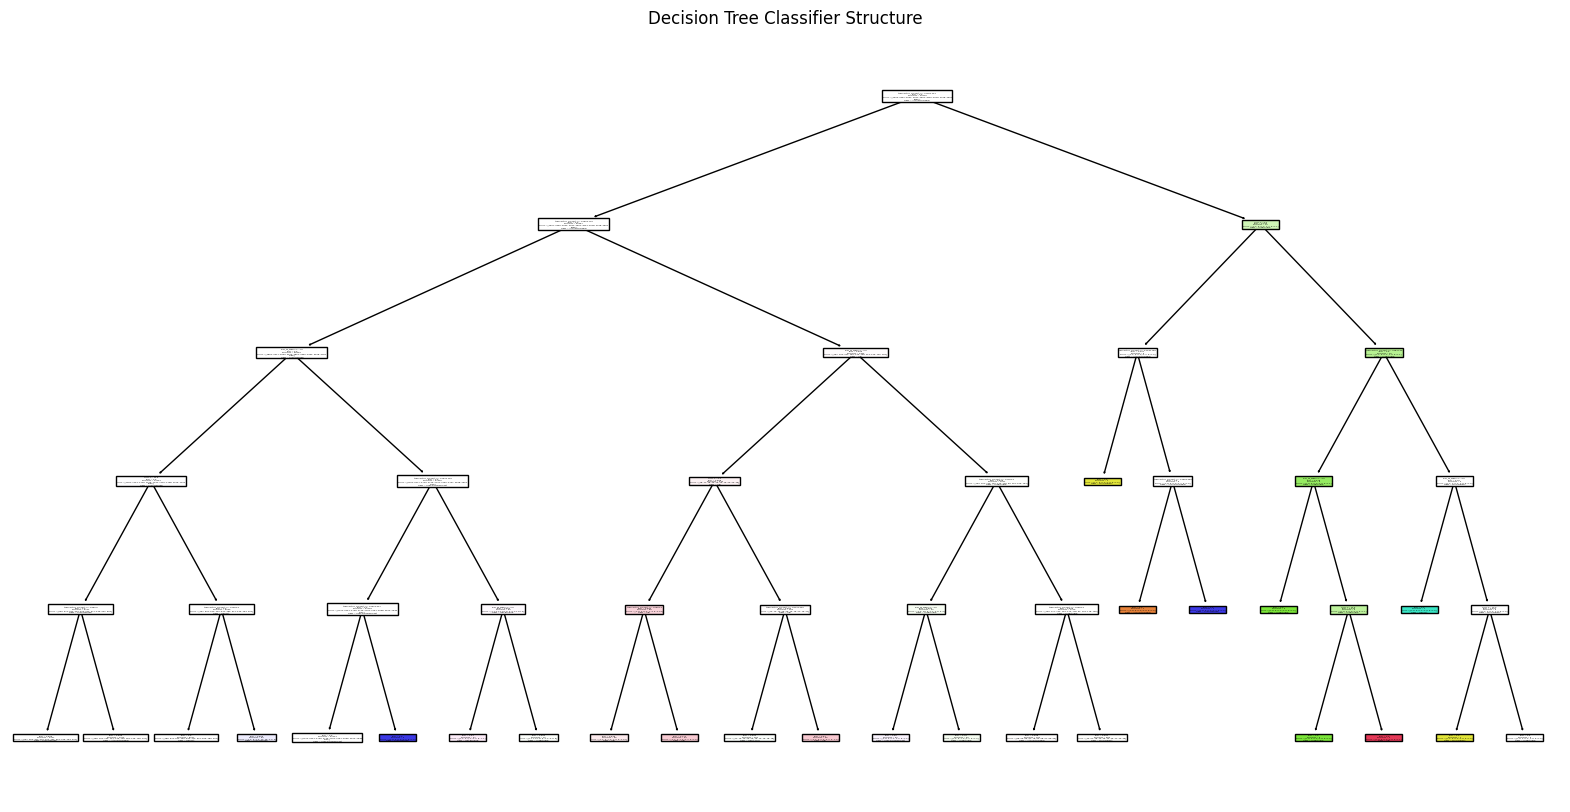

In [32]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X_class.columns, class_names=le_type.classes_, filled=True)
plt.title("Decision Tree Classifier Structure")
plt.show()

What This Does
Classification: Predicts transaction_type

Shows Confusion Matrix

Shows Feature Importance

Shows Decision Tree Diagram

Regression: Predicts transaction_amount

Shows Actual vs. Predicted Scatter Plot

Shows Feature Importance

Prints RMSE & R² score


NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [33]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)